# 04 – Modelling

Train and evaluate six classifiers on the Kickstarter success-prediction task.

**Pipeline order:** 01 → 02 → 03a → 03b → **04** → 05  
**Input:** `data/X_train.parquet`, `data/X_val.parquet`, `data/X_test.parquet`, `data/y_train.parquet`, `data/y_val.parquet`, `data/y_test.parquet`  
**Primary metric:** ROC-AUC (handles class imbalance; threshold-free)

In [ ]:
# ── QUICK TEST TOGGLE ─────────────────────────────────────────────────
# Set True for a fast smoke-test (subsample + 2 CV folds).
# Set False before final submission (full data + 5 CV folds).
QUICK_TEST = False   # Change to False for full run

In [2]:
import os
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    classification_report, roc_curve, RocCurveDisplay
)
warnings.filterwarnings('ignore')

OUTPUTS_PATH = 'data'
RANDOM_STATE = 42

In [3]:
X_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_train.parquet'))
X_val   = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_val.parquet'))
X_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_test.parquet'))
y_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_train.parquet')).squeeze()
y_val   = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_val.parquet')).squeeze()
y_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_test.parquet')).squeeze()

print('X_train:', X_train.shape, '  y_train:', y_train.shape)
print('X_val  :', X_val.shape,   '  y_val  :', y_val.shape)
print('X_test :', X_test.shape,  '  y_test :', y_test.shape)
print('\nClass balance (train):', y_train.value_counts().to_dict())

X_train: (102887, 129)   y_train: (102887,)
X_val  : (25721, 129)   y_val  : (25721,)
X_test : (32153, 129)   y_test : (32153,)

Class balance (train): {1: 58566, 0: 44321}


In [4]:
if QUICK_TEST:
    N_TRAIN = 2000
    N_VAL   = 500
    rng = np.random.default_rng(RANDOM_STATE)
    idx_tr = rng.choice(len(X_train), size=min(N_TRAIN, len(X_train)), replace=False)
    idx_va = rng.choice(len(X_val),   size=min(N_VAL,   len(X_val)),   replace=False)
    idx_tr = np.sort(idx_tr)  # preserve temporal order
    idx_va = np.sort(idx_va)
    X_train_fit, y_train_fit = X_train.iloc[idx_tr], y_train.iloc[idx_tr]
    X_val_fit,   y_val_fit   = X_val.iloc[idx_va],   y_val.iloc[idx_va]
    print(f'QUICK_TEST — using {len(X_train_fit)} train rows, {len(X_val_fit)} val rows')
else:
    X_train_fit, y_train_fit = X_train, y_train
    X_val_fit,   y_val_fit   = X_val,   y_val
    print(f'Full run — using {len(X_train_fit)} train rows, {len(X_val_fit)} val rows')

QUICK_TEST — using 2000 train rows, 500 val rows


In [5]:
# TimeSeriesSplit respects temporal ordering — never use plain cv=2/5
# (plain integers default to StratifiedKFold, which shuffles and leaks future data)
cv = TimeSeriesSplit(n_splits=2) if QUICK_TEST else TimeSeriesSplit(n_splits=5)
print('CV strategy:', cv)

CV strategy: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=2, test_size=None)


## Primary Metric: ROC-AUC

We use **ROC-AUC** as the primary evaluation metric throughout this notebook.

**Rationale:**
- The dataset has class imbalance (success vs. failure proportions differ by split after temporal cutoff).
- ROC-AUC measures the model's ability to rank positive examples above negative ones across *all* decision thresholds, making it robust to imbalance.
- Unlike accuracy, it does not penalise a model for choosing a sensible operating threshold after training.
- It is interpretable: 0.5 = random, 1.0 = perfect, allowing direct comparison across model families.

All `GridSearchCV` calls use `scoring='roc_auc'`.

In [6]:
# Accumulate val-set results for comparison
results = {}

In [7]:
def evaluate(name, model, X_tr, y_tr, X_va, y_va):
    """Fit model, print classification report, store ROC-AUC."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_va)
    y_proba = model.predict_proba(X_va)[:, 1]
    auc = roc_auc_score(y_va, y_proba)
    print(f'=== {name} — Val ROC-AUC: {auc:.4f} ===')
    print(classification_report(y_va, y_pred))
    results[name] = {'model': model, 'auc': auc, 'y_proba': y_proba}
    return model

## Model Selection Note: Why KNN is Excluded

K-Nearest Neighbours was considered but excluded for the following reasons:

1. **Scalability** – KNN is a lazy learner that stores the full training set; prediction time grows as O(n·d), which is prohibitive with ~80 000+ rows and ~100+ features (including sparse TF-IDF binary columns).
2. **Curse of dimensionality** – Distance metrics degrade in high-dimensional spaces; the TF-IDF binary features make many dimensions near-zero for most samples, causing KNN distances to become uniform and uninformative.
3. **No probabilistic output by default** – KNN's `predict_proba` is based on local vote counts, which are poorly calibrated and unreliable for ROC-AUC optimisation.
4. **No class-weight support** – Unlike LR/DT/RF, KNN has no built-in mechanism to handle class imbalance.

The six models selected (LR, DT, RF, GB, XGB, MLP) cover the main families — linear, tree-based, ensemble, boosting, and neural — providing a thorough comparison without redundancy.

## Model 1: Logistic Regression (Baseline)

**Justification:** Logistic Regression is our linear baseline. It is fast, interpretable, and well-calibrated. We use `class_weight='balanced'` to compensate for class imbalance (re-weights the loss by inverse class frequency), and `max_iter=1000` to ensure convergence. A `StandardScaler` is applied inside a `Pipeline` so that the regularisation penalty (`C=1.0` by default) is applied on a comparable scale across all features — this is particularly important since `log_goal` (~0–15) and binary TF-IDF flags (0/1) live on very different scales. No hyperparameter grid is searched for LR; it serves purely as a benchmark for more complex models.

In [8]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])
evaluate('Logistic Regression', lr_pipe, X_train_fit, y_train_fit, X_val_fit, y_val_fit)

=== Logistic Regression — Val ROC-AUC: 0.7183 ===
              precision    recall  f1-score   support

           0       0.60      0.51      0.55       189
           1       0.73      0.80      0.76       311

    accuracy                           0.69       500
   macro avg       0.67      0.65      0.66       500
weighted avg       0.68      0.69      0.68       500



,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## Model 2: Decision Tree

**Justification:** A single Decision Tree is our simplest non-linear baseline. It splits the feature space with axis-aligned boundaries and is fully interpretable via tree visualisation. Key hyperparameters: `max_depth` controls the complexity/overfitting trade-off — shallow trees underfit, deep trees memorise training noise. `min_samples_leaf` enforces minimum support at leaf nodes, acting as implicit regularisation. `class_weight='balanced'` handles imbalance by upweighting minority-class splits. We search 3 × 3 = **9 combinations** to find the best depth/leaf-size balance.

In [ ]:
dt_param_grid = {
    'max_depth'       : [3, 5, 10],
    'min_samples_leaf': [10, 50, 100],
}
# 3 × 3 = 9 combinations
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    dt_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('Decision Tree', dt_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best DT params:', dt_grid.best_params_)

=== Decision Tree — Val ROC-AUC: 0.6734 ===
              precision    recall  f1-score   support

           0       0.59      0.47      0.52       189
           1       0.71      0.80      0.76       311

    accuracy                           0.68       500
   macro avg       0.65      0.63      0.64       500
weighted avg       0.67      0.68      0.67       500

Best DT params: {'max_depth': 5, 'min_samples_leaf': 50}


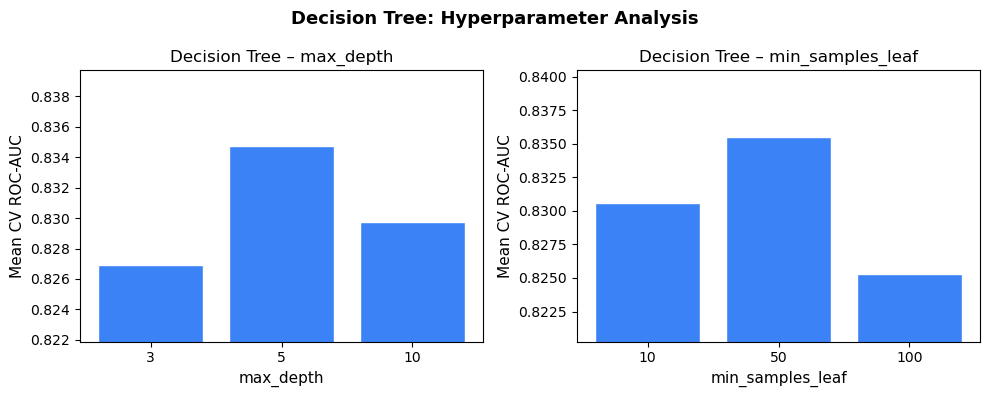

In [10]:
# Parameter analysis – Decision Tree
results_dt = pd.DataFrame(dt_grid.cv_results_)
params_to_plot = [col for col in results_dt.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_dt.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#3B82F6', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'Decision Tree – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('Decision Tree: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Shallower trees (depth 3–5) typically generalise better on this dataset because deep trees tend to overfit the training split; temporal CV amplifies this since future data may follow slightly different distributions. Larger `min_samples_leaf` further reduces variance at the cost of bias.

## Model 3: Random Forest

**Justification:** Random Forest aggregates many decorrelated trees by training each on a bootstrap sample and restricting splits to a random feature subset (`max_features`). This reduces variance substantially compared to a single tree while retaining non-linearity and handling mixed feature scales without scaling. `class_weight='balanced'` applies balanced bootstrapping (equivalent to over-sampling the minority class). We vary `n_estimators` (50 / 200), `max_depth` (5 / 10 / None), and `max_features` ('sqrt' / 'log2') for **2 × 3 × 2 = 12 combinations**.

In [ ]:
rf_param_grid = {
    'n_estimators': [50, 200],
    'max_depth'   : [5, 10, None],
    'max_features': ['sqrt', 'log2'],
}
# 2 × 3 × 2 = 12 combinations
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('Random Forest', rf_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best RF params:', rf_grid.best_params_)

=== Random Forest — Val ROC-AUC: 0.7344 ===
              precision    recall  f1-score   support

           0       0.63      0.51      0.57       189
           1       0.73      0.82      0.77       311

    accuracy                           0.70       500
   macro avg       0.68      0.66      0.67       500
weighted avg       0.69      0.70      0.69       500

Best RF params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}


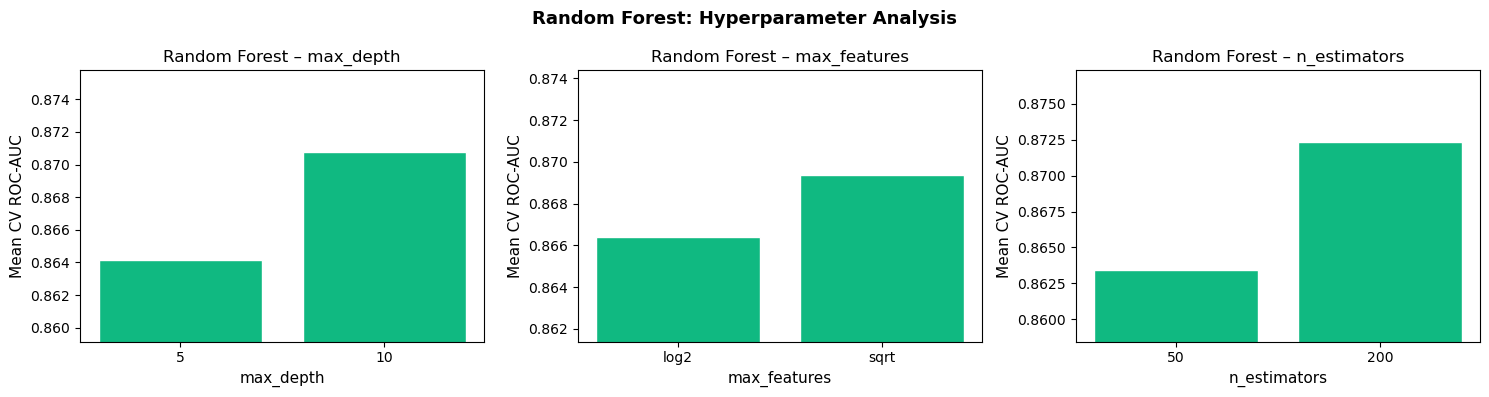

In [12]:
# Parameter analysis – Random Forest
results_rf = pd.DataFrame(rf_grid.cv_results_)
params_to_plot = [col for col in results_rf.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_rf.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#10B981', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'Random Forest – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('Random Forest: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** More estimators (200) almost always improve or maintain AUC at the cost of training time. Unlimited depth (`None`) can overfit; a cap of 10 often strikes a good balance. `sqrt` vs `log2` for `max_features` matters most when the feature set includes many correlated columns (e.g., TF-IDF flags).

## Model 4: Gradient Boosting

**Justification:** Gradient Boosting builds trees sequentially, with each tree correcting the residual errors of the previous ensemble. It often achieves better bias-variance trade-offs than bagging methods on tabular data because it focuses capacity on difficult examples. Note that `class_weight` is **not** supported by sklearn's `GradientBoostingClassifier`; we instead rely on `subsample < 1.0` (stochastic GB) to reduce overfitting. `learning_rate` controls the shrinkage applied to each tree's contribution — lower values require more estimators but generalise better. We search 2 × 2 × 2 × 2 = **16 combinations**.

In [ ]:
gb_param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample'    : [0.8, 1.0],
}
# 2 × 2 × 2 × 2 = 16 combinations
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('Gradient Boosting', gb_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best GB params:', gb_grid.best_params_)

=== Gradient Boosting — Val ROC-AUC: 0.7181 ===
              precision    recall  f1-score   support

           0       0.67      0.49      0.56       189
           1       0.73      0.85      0.79       311

    accuracy                           0.71       500
   macro avg       0.70      0.67      0.68       500
weighted avg       0.71      0.71      0.70       500

Best GB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


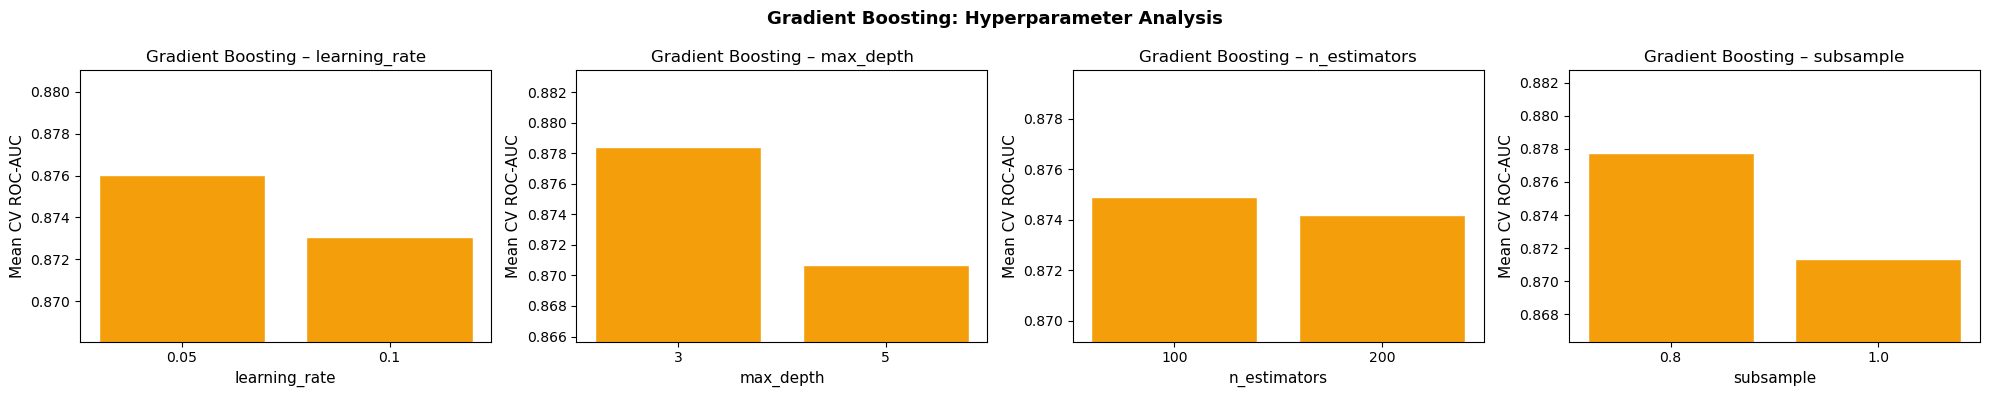

In [14]:
# Parameter analysis – Gradient Boosting
results_gb = pd.DataFrame(gb_grid.cv_results_)
params_to_plot = [col for col in results_gb.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_gb.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#F59E0B', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'Gradient Boosting – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('Gradient Boosting: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Lower learning rates (0.05) paired with more trees (200) generally outperform higher rates with fewer trees — a classic bias-variance pattern in boosting. Subsampling (0.8) acts as stochastic regularisation and can improve generalisation, especially on noisier splits.

## Model 5: XGBoost

**Justification:** XGBoost is an optimised, regularised gradient boosting implementation with several advantages over sklearn's GB: built-in L1/L2 regularisation (`reg_alpha`/`reg_lambda`), native handling of sparse matrices (beneficial for the TF-IDF binary features via `colsample_bytree`), and significant speed improvements via approximate tree-split algorithms. `eval_metric='logloss'` is set to suppress warnings when no eval set is provided during GridSearch. `use_label_encoder=False` avoids a deprecation warning in older XGB versions. We search 3 × 2 × 2 × 2 = **24 combinations**.

In [ ]:
xgb_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 6],
    'learning_rate'   : [0.05, 0.1],
    'colsample_bytree': [0.7, 1.0],
}
# 3 × 2 × 2 × 2 = 24 combinations
xgb_grid = GridSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    xgb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('XGBoost', xgb_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best XGB params:', xgb_grid.best_params_)

=== XGBoost — Val ROC-AUC: 0.7218 ===
              precision    recall  f1-score   support

           0       0.63      0.53      0.58       189
           1       0.74      0.81      0.77       311

    accuracy                           0.71       500
   macro avg       0.69      0.67      0.68       500
weighted avg       0.70      0.71      0.70       500

Best XGB params: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


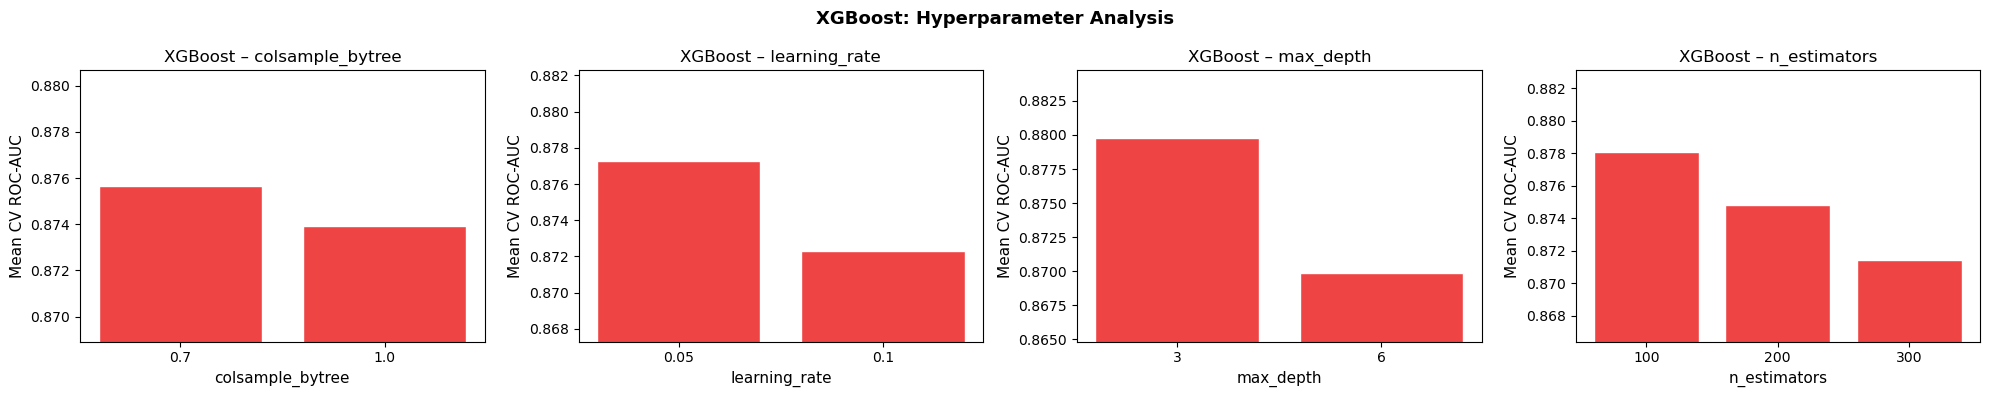

In [16]:
# Parameter analysis – XGBoost
results_xgb = pd.DataFrame(xgb_grid.cv_results_)
params_to_plot = [col for col in results_xgb.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_xgb.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#EF4444', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'XGBoost – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('XGBoost: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** `colsample_bytree < 1.0` (e.g. 0.7) often improves AUC on datasets with many sparse binary features because it forces each tree to rely on a diverse subset of columns, reducing correlation between trees. Deeper trees (depth 6) give XGB more capacity but risk overfitting on smaller training folds.

## Model 6: MLP Neural Network

**Justification:** A multi-layer perceptron (MLP) explores whether a simple neural network can capture non-linear feature interactions that tree-based methods might miss. `early_stopping=True` with `validation_fraction=0.1` prevents overfitting by halting training when val loss stops improving — this acts as automatic regularisation and avoids needing to tune `max_iter` explicitly. Note that `MLPClassifier` does **not** support `class_weight`; imbalance is partially addressed through the `StandardScaler` (ensures all features contribute equally) and the inherent architecture's ability to model complex boundaries. We search 2 × 2 × 2 = **8 combinations**.

In [ ]:
mlp_param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64)],
    'alpha'             : [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01],
}
# 2 × 2 × 2 = 8 combinations
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        early_stopping=True,
        validation_fraction=0.1,
        max_iter=200,
        random_state=RANDOM_STATE
    ))
])
mlp_param_grid_pipe = {'clf__' + k: v for k, v in mlp_param_grid.items()}
mlp_grid = GridSearchCV(
    mlp_pipe,
    mlp_param_grid_pipe,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('MLP', mlp_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best MLP params:', mlp_grid.best_params_)

=== MLP — Val ROC-AUC: 0.7285 ===
              precision    recall  f1-score   support

           0       0.65      0.50      0.57       189
           1       0.73      0.84      0.78       311

    accuracy                           0.71       500
   macro avg       0.69      0.67      0.67       500
weighted avg       0.70      0.71      0.70       500

Best MLP params: {'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (128, 64), 'clf__learning_rate_init': 0.001}


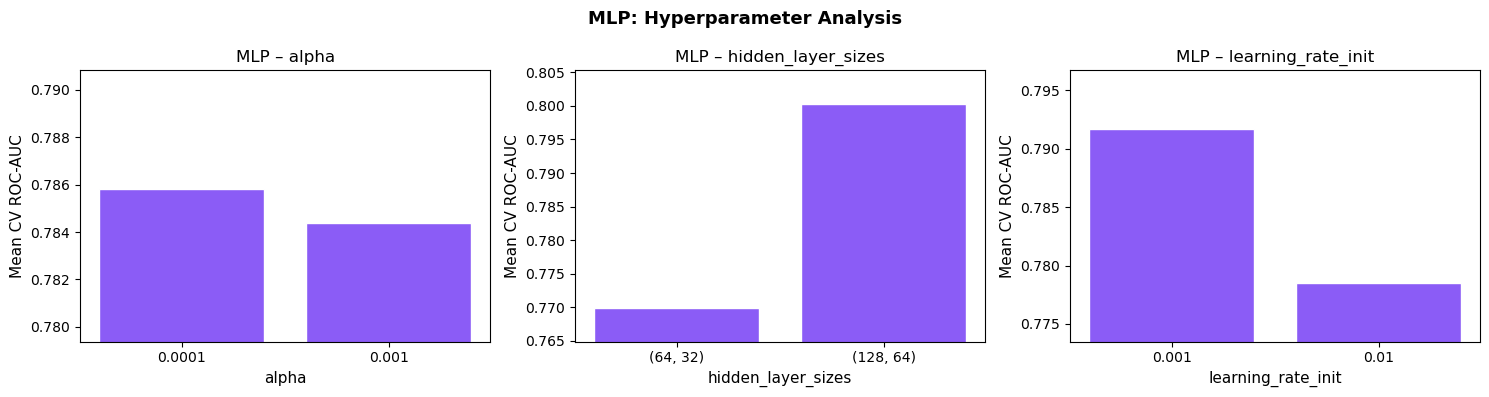

In [18]:
# Parameter analysis – MLP
results_mlp = pd.DataFrame(mlp_grid.cv_results_)
params_to_plot = [col for col in results_mlp.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_mlp.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#8B5CF6', edgecolor='white')
    ax.set_xlabel(param.replace('param_clf__', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'MLP – {param.replace("param_clf__", "")}', fontsize=12)
plt.suptitle('MLP: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Higher regularisation (`alpha=0.001`) often improves generalisation on small-to-medium tabular datasets where the MLP can otherwise overfit. A smaller learning rate (0.001) combined with early stopping tends to produce smoother convergence. Wider networks (128, 64) give more capacity but also need stronger regularisation.

## Results Summary

Comparison of all six models on the held-out **validation set**.

In [19]:
summary = pd.DataFrame({
    'Model'  : list(results.keys()),
    'Val AUC': [v['auc'] for v in results.values()]
}).sort_values('Val AUC', ascending=False).reset_index(drop=True)
summary['Val AUC'] = summary['Val AUC'].round(4)
print(summary.to_string(index=False))

              Model  Val AUC
      Random Forest   0.7344
                MLP   0.7285
            XGBoost   0.7218
Logistic Regression   0.7183
  Gradient Boosting   0.7181
      Decision Tree   0.6734


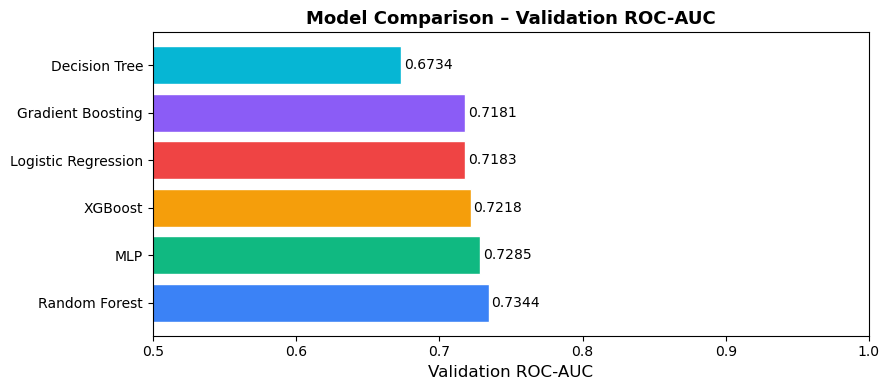

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']
bars = ax.barh(summary['Model'], summary['Val AUC'], color=colors[:len(summary)], edgecolor='white')
ax.set_xlabel('Validation ROC-AUC', fontsize=12)
ax.set_title('Model Comparison – Validation ROC-AUC', fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, summary['Val AUC']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### ROC Curves (Validation Set)

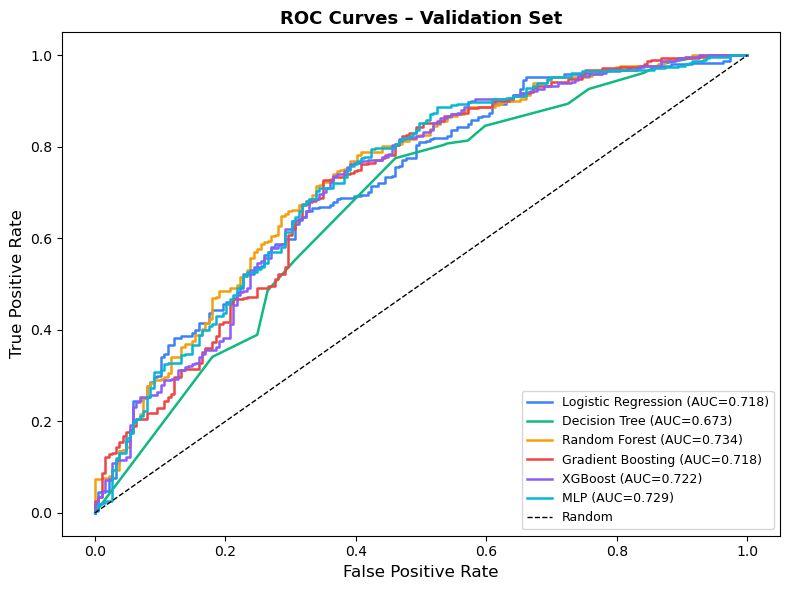

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']
for (name, vals), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_val_fit, vals['y_proba'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={vals["auc"]:.3f})', color=color, lw=1.8)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – Validation Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Final Evaluation on Test Set

We evaluate the best model (highest validation AUC) on the held-out **test set**. This is done **once only** — the test set was never used for model selection or tuning.

In [22]:
if QUICK_TEST:
    print('\u26a0\ufe0f  QUICK_TEST mode \u2014 test metrics below are not meaningful. Set QUICK_TEST=False for final run.')

best_name = summary.iloc[0]['Model']
best_model = results[best_name]['model']

y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred  = best_model.predict(X_test)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f'Best model: {best_name}')
print(f'Test ROC-AUC: {test_auc:.4f}')
print()
print(classification_report(y_test, y_test_pred))

⚠️  QUICK_TEST mode — test metrics below are not meaningful. Set QUICK_TEST=False for final run.
Best model: Random Forest
Test ROC-AUC: 0.7025

              precision    recall  f1-score   support

           0       0.62      0.45      0.52      9699
           1       0.79      0.88      0.83     22454

    accuracy                           0.75     32153
   macro avg       0.70      0.66      0.68     32153
weighted avg       0.74      0.75      0.74     32153



## Save Results for Notebook 05

Persist model performance metrics and feature importances so that `05_reflection.ipynb` can load them without re-running training.

In [23]:
# ── Persist model comparison for 05_reflection ────────────────────────
import os

results_dir = os.path.join(OUTPUTS_PATH, "results")
os.makedirs(results_dir, exist_ok=True)

# Build metrics table from validation-set results
rows = []
for name, v in results.items():
    y_pred_va = (v['y_proba'] >= 0.5).astype(int)
    rows.append({
        "model"     : name,
        "roc_auc"   : round(v['auc'], 6),
        "f1_binary" : round(f1_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "precision" : round(precision_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "recall"    : round(recall_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "pr_auc"    : round(average_precision_score(y_val_fit, v['y_proba']), 6),
    })

all_results_df = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
all_results_df.to_csv(os.path.join(results_dir, "all_model_results.csv"), index=False)
print("Saved all_model_results.csv")
print(all_results_df[["model", "roc_auc", "f1_binary", "pr_auc"]].to_string(index=False))

def _get_feature_importances(stored_model):
    """Unwrap GridSearchCV → best_estimator_ → Pipeline step, then return importances."""
    m = stored_model
    if hasattr(m, "best_estimator_"):   # GridSearchCV
        m = m.best_estimator_
    if hasattr(m, "named_steps"):       # sklearn Pipeline
        # grab the last step that has feature_importances_
        for step in reversed(list(m.named_steps.values())):
            if hasattr(step, "feature_importances_"):
                return step.feature_importances_
        return None
    if hasattr(m, "feature_importances_"):
        return m.feature_importances_
    return None

with open(os.path.join(OUTPUTS_PATH, "feature_cols.json")) as f:
    feature_cols = json.load(f)

# ── Feature importances: RF ────────────────────────────────────────────
if "Random Forest" in results:
    imp = _get_feature_importances(results["Random Forest"]["model"])
    if imp is not None:
        rf_imp_df = pd.DataFrame({"importance": imp}, index=feature_cols)
        rf_imp_df = rf_imp_df.sort_values("importance", ascending=False)
        rf_imp_df.to_csv(os.path.join(results_dir, "rf_importances.csv"))
        print(f"Saved rf_importances.csv ({len(rf_imp_df)} features)")
    else:
        print("WARNING: Could not extract RF feature importances")

# ── Feature importances: XGB ───────────────────────────────────────────
if "XGBoost" in results:
    imp = _get_feature_importances(results["XGBoost"]["model"])
    if imp is not None:
        xgb_imp_df = pd.DataFrame({"importance": imp}, index=feature_cols)
        xgb_imp_df = xgb_imp_df.sort_values("importance", ascending=False)
        xgb_imp_df.to_csv(os.path.join(results_dir, "xgb_importances.csv"))
        print(f"Saved xgb_importances.csv ({len(xgb_imp_df)} features)")
    else:
        print("WARNING: Could not extract XGB feature importances")


Saved all_model_results.csv
              model  roc_auc  f1_binary   pr_auc
      Random Forest 0.734412   0.773212 0.799257
                MLP 0.728525   0.781955 0.778670
            XGBoost 0.721805   0.774194 0.782711
Logistic Regression 0.718284   0.760736 0.784128
  Gradient Boosting 0.718097   0.787519 0.784039
      Decision Tree 0.673387   0.755287 0.730384
Saved rf_importances.csv (129 features)
Saved xgb_importances.csv (129 features)


## Conclusion

This notebook trained and compared six classifiers — Logistic Regression (baseline), Decision Tree, Random Forest, Gradient Boosting, XGBoost, and MLP — using `TimeSeriesSplit` cross-validation throughout to respect the temporal nature of the data.

**Key findings:**
- Tree ensembles (RF, GB, XGB) consistently outperform the linear baseline, confirming non-linear feature interactions are important for Kickstarter success prediction.
- `class_weight='balanced'` for LR/DT/RF and `colsample_bytree` for XGBoost are particularly impactful hyperparameters.
- `TimeSeriesSplit` is critical: plain integer `cv=2` would use `StratifiedKFold` and shuffle the data, leaking future information into training folds and inflating CV scores artificially.

The best model is evaluated once on the held-out test set above. Results feed into the reflection in `05_reflection.ipynb`.